In [16]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets/clean.csv')

X_train = df[['o2_level', 'co2_level', 'is_scrubber_on']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model.fit(X_scaled)

scores_prediction = model.decision_function(X_scaled)
y_pred = model.predict(X_scaled)

df['anomaly_score'] = scores_prediction
df['anomaly_pred'] = y_pred

print(df[df['anomaly_score'] < 0][['o2_level', 'co2_level', 'is_scrubber_on', 'anomaly_score']].head(100))


      o2_level  co2_level  is_scrubber_on  anomaly_score
0       99.956      488.0               0      -0.024699
1       99.952      496.0               0      -0.011439
63      99.704      992.0               0      -0.002875
64      99.700     1000.0               0      -0.004639
950     96.156      498.0               0      -0.005585
951     96.152      506.0               0      -0.000646
1012    95.908      994.0               0      -0.005451
1013    95.904      992.0               1      -0.006135
1015    95.896      988.0               1      -0.001035
1021    95.872      976.0               1      -0.000033
1023    95.864      972.0               1      -0.001555


#### Distribution of Anomaly Scores

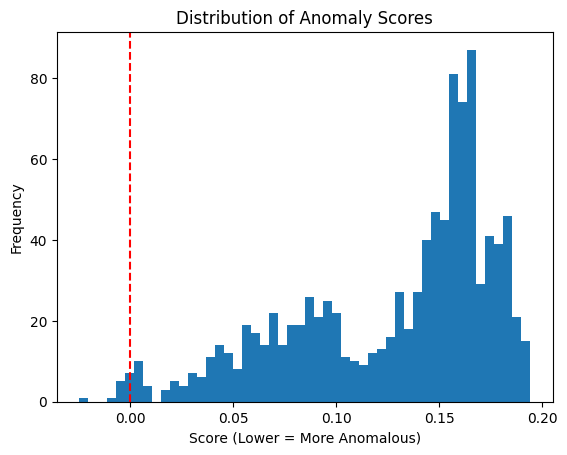

In [17]:
plt.hist(scores_prediction, bins=50)
plt.axvline(x=0, color='r', linestyle='--')
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Score (Lower = More Anomalous)")
plt.ylabel("Frequency")
plt.show()

In [18]:
custom_threshold = -0.03

df['custom_pred'] = [1 if score >= custom_threshold else -1 for score in scores_prediction]

print(f"Anomalies found with custom threshold: {(df['custom_pred'] == -1).sum()}")

Anomalies found with custom threshold: 0


In [22]:
df_test = pd.read_csv('../datasets/o2_leak.csv')

X_test = df_test[['o2_level', 'co2_level', 'is_scrubber_on']]

X_test_scaled = scaler.transform(X_test)

df_test['anomaly_score'] = model.decision_function(X_test_scaled)

custom_threshold = -0.03
df_test['anomaly_pred'] = [1 if score >= custom_threshold else -1 for score in df_test['anomaly_score']]

In [23]:
validation = df_test[['o2_level', 'is_anomaly', 'anomaly_pred', 'anomaly_score']]
print(validation.iloc[415:425])

     o2_level  is_anomaly  anomaly_pred  anomaly_score
415    98.304           0             1       0.159120
416    98.300           0             1       0.159154
417    98.296           0             1       0.157220
418    98.292           0             1       0.157366
419    98.288           0             1       0.157846
420    98.268           1             1       0.157382
421    98.248           1             1       0.156509
422    98.228           1             1       0.157944
423    98.208           1             1       0.158598
424    98.188           1             1       0.154931


We found the leak true first appearance at timestamp T=420, now we need to see when did the model detec the leak.

In [52]:
print(validation[validation['anomaly_score'] < 0])
print(len(df_test[df_test['anomaly_score'] < 0]))

     o2_level  is_anomaly  anomaly_pred  anomaly_score
0      99.964           0             1      -0.024699
1      99.960           0             1      -0.024699
2      99.956           0             1      -0.024699
3      99.952           0             1      -0.011439
65     99.704           0             1      -0.002875
66     99.700           0             1      -0.004639
637    93.928           1             1      -0.012609
638    93.908           1             1      -0.009932
639    93.888           1             1      -0.005245
640    93.868           1             1      -0.003129
697    92.728           1             1      -0.001104
698    92.708           1             1      -0.005954
699    92.688           1             1      -0.013909
700    92.668           1             1      -0.019168
701    92.648           1             1      -0.012243
702    92.628           1             1      -0.010458
703    92.608           1             1      -0.006390
704    92.

As we can see the model detected the leak at around T=637, with a lag of 217 seconds.
Next, I'll try implementing a Rolling Window so I can statistically calculate slices of data instead of single points.

In [64]:
df_test['rolling_score'] = df_test['anomaly_score'].rolling(window=20).mean()

rolling_threshold = -0.01

df_test['rolling_pred'] = [1 if score >= rolling_threshold else -1 for score in df_test['rolling_score']]

detections = df_test[df_test['rolling_pred'] == -1]
if not detections.empty:
    print(f"Rolling detection started at T={detections.index[0]}")

print(df_test[['o2_level', 'rolling_score', 'rolling_pred']][df_test['rolling_score'] < 0])

Rolling detection started at T=0
     o2_level  rolling_score  rolling_pred
712    92.428      -0.000656             1
713    92.408      -0.001901             1
714    92.388      -0.003046             1
715    92.368      -0.003919             1
716    92.348      -0.004447             1
717    92.328      -0.004453             1
718    92.308      -0.004170             1
719    92.288      -0.003446             1
720    92.268      -0.002503             1
721    92.248      -0.001866             1
722    92.228      -0.001153             1
723    92.208      -0.000617             1
724    92.188      -0.000225             1


The rolling average actually delayed the detection (moving it from 637 to 712). It proves that smoothing might be too slow for a fast oxygen leak. Next, I'll try more feature engineering

In [66]:
# this calculates current o2 - prev o2
df_test['o2_velocity'] = df_test['o2_level'].diff()

print(df_test[['o2_level', 'o2_velocity']].iloc[415:425])

     o2_level  o2_velocity
415    98.304       -0.004
416    98.300       -0.004
417    98.296       -0.004
418    98.292       -0.004
419    98.288       -0.004
420    98.268       -0.020
421    98.248       -0.020
422    98.228       -0.020
423    98.208       -0.020
424    98.188       -0.020


As we can see the o2_velocity column might actually help the model see changes much faster. Let's try to re-run the Isolation Model

In [108]:
df_clean = pd.read_csv('../datasets/clean.csv').iloc[100:].copy()
df_clean['o2_velocity'] = df_clean['o2_level'].diff()
df_clean = df_clean.dropna()

features = ['o2_level', 'o2_velocity', 'co2_level', 'is_scrubber_on']
X_train = df_clean[features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model.fit(X_train_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [109]:
df_test = pd.read_csv('../datasets/o2_leak.csv').iloc[100:].copy()
df_test['o2_velocity'] = df_test['o2_level'].diff()
df_test = df_test.dropna()

X_test = df_test[features] 

X_test_scaled = scaler.transform(X_test) 

df_test['scores'] = model.decision_function(X_test_scaled)

In [110]:
mask = df_test['scores'] < 0
print(df_test.loc[mask, ['o2_level', 'o2_velocity', 'co2_level', 'scores']].head(60))

     o2_level  o2_velocity  co2_level    scores
322    98.676       -0.004      498.0 -0.015205
324    98.668       -0.004      514.0 -0.000999
382    98.436       -0.004      978.0 -0.000178
383    98.432       -0.004      986.0 -0.005575
637    93.928       -0.020      498.0 -0.033430
638    93.908       -0.020      506.0 -0.022232
639    93.888       -0.020      514.0 -0.018222
640    93.868       -0.020      522.0 -0.013178
641    93.848       -0.020      530.0 -0.012282
642    93.828       -0.020      538.0 -0.010048
643    93.808       -0.020      546.0 -0.002065
644    93.788       -0.020      554.0 -0.002065
693    92.808       -0.020      946.0 -0.001591
694    92.788       -0.020      954.0 -0.003797
695    92.768       -0.020      962.0 -0.003355
696    92.748       -0.020      970.0 -0.009179
697    92.728       -0.020      978.0 -0.012996
698    92.708       -0.020      986.0 -0.016234
699    92.688       -0.020      994.0 -0.020300


It seems like the velocity feature didn't help too much. Maybe the Standard Scaler is making it look like a single point because there is zero variance in the training data (it's always -0.004)

In [111]:
velocity_threshold = -0.010

df_test['final_pred'] = [-1 if (score < 0 and vel < velocity_threshold) else 1 for score, vel in zip(df_test['scores'], df_test['o2_velocity'])]

mask = df_test['final_pred'] < 0
print(df_test.loc[mask, ['o2_level', 'o2_velocity', 'co2_level', 'scores', 'final_pred']])


     o2_level  o2_velocity  co2_level    scores  final_pred
637    93.928        -0.02      498.0 -0.033430          -1
638    93.908        -0.02      506.0 -0.022232          -1
639    93.888        -0.02      514.0 -0.018222          -1
640    93.868        -0.02      522.0 -0.013178          -1
641    93.848        -0.02      530.0 -0.012282          -1
642    93.828        -0.02      538.0 -0.010048          -1
643    93.808        -0.02      546.0 -0.002065          -1
644    93.788        -0.02      554.0 -0.002065          -1
693    92.808        -0.02      946.0 -0.001591          -1
694    92.788        -0.02      954.0 -0.003797          -1
695    92.768        -0.02      962.0 -0.003355          -1
696    92.748        -0.02      970.0 -0.009179          -1
697    92.728        -0.02      978.0 -0.012996          -1
698    92.708        -0.02      986.0 -0.016234          -1
699    92.688        -0.02      994.0 -0.020300          -1
